In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import zipfile

zip_path = "/content/drive/MyDrive/archive.zip"
extract_path = "/content/rice_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done")

Done


In [10]:
import os

os.listdir("/content/rice_data/Rice_Image_Dataset")

['Basmati',
 'Arborio',
 'Ipsala',
 'Jasmine',
 'Rice_Citation_Request.txt',
 'Karacadag']

Dataset Selection

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

from PIL import Image

Dataset Selection

In [12]:
dataset_path = "/content/rice_data/Rice_Image_Dataset"

classes = [
    c for c in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path,c))
]

print(classes)

['Basmati', 'Arborio', 'Ipsala', 'Jasmine', 'Karacadag']


In [13]:
classes = [
    c for c in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path,c))
    and len(os.listdir(os.path.join(dataset_path,c))) > 0
]

print(classes)

['Basmati', 'Arborio', 'Ipsala', 'Jasmine', 'Karacadag']


Number of classes

In [14]:
print("Number of classes:", len(classes))

Number of classes: 5


Number of images per class

In [15]:
for cls in classes:
    total = len(
        os.listdir(os.path.join(dataset_path, cls))
    )
    print(cls,":",total)

Basmati : 15000
Arborio : 15000
Ipsala : 15000
Jasmine : 15000
Karacadag : 15000


Check class imbalance

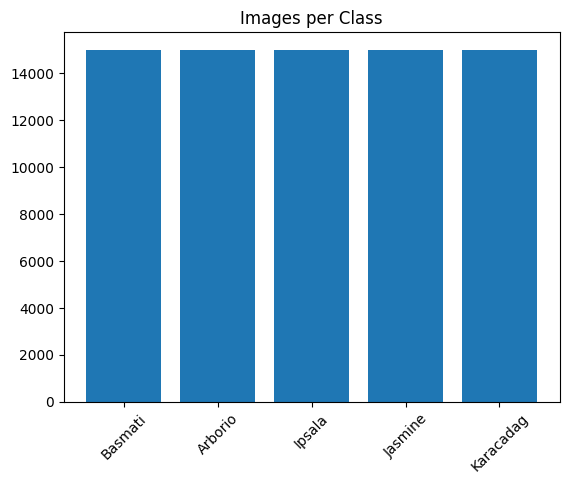

In [16]:
class_count = {}

for cls in classes:
    class_count[cls] = len(
        os.listdir(os.path.join(dataset_path,cls))
    )


plt.bar(
    class_count.keys(),
    class_count.values()
)

plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

Image Dimensions

In [17]:
sample_image = os.path.join(
    dataset_path,
    classes[0],
    os.listdir(
        os.path.join(dataset_path,classes[0])
    )[0]
)


img = Image.open(sample_image)

print("Width,Height:", img.size)

print(
    "Channels:",
    len(img.getbands())
)

Width,Height: (250, 250)
Channels: 3


Display Sample Images

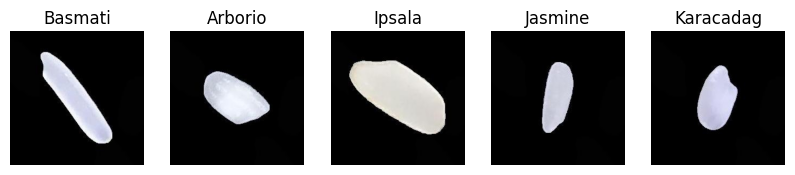

In [18]:
plt.figure(figsize=(10,5))


for i,cls in enumerate(classes):

    img_name = os.listdir(
        os.path.join(dataset_path,cls)
    )[0]


    img = Image.open(
        os.path.join(
            dataset_path,
            cls,
            img_name
        )
    )

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")


plt.show()

Problem Statement

The objective of this project is to build a CNN model
that can classify rice grain images into 5 categories:
Arborio, Basmati, Ipsala, Jasmine, and Karacadag.

Rice classification is important for quality checking,
automation in agriculture, and reducing manual inspection.

The expected output of the model is the predicted rice class.

In [19]:
import tensorflow as tf

from tensorflow.keras import layers, models

Data Preprocessing
Train Validation Split + Resize

In [20]:
train_ds = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="training",

    seed=42,

    image_size=(224,224),

    batch_size=32
)


val_ds = tf.keras.utils.image_dataset_from_directory(

    dataset_path,

    validation_split=0.2,

    subset="validation",

    seed=42,

    image_size=(224,224),

    batch_size=32
)

Found 75000 files belonging to 5 classes.
Using 60000 files for training.
Found 75000 files belonging to 5 classes.
Using 15000 files for validation.


Data Augmentation

In [21]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2),

    layers.RandomTranslation(0.1,0.1),

    layers.RandomContrast(0.2)

])

CNN Model Implementation

In [22]:
model1 = models.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),


    layers.Conv2D(32,3,activation='relu'),

    layers.MaxPooling2D(),


    layers.Conv2D(64,3,activation='relu'),

    layers.MaxPooling2D(),


    layers.Conv2D(128,3,activation='relu'),

    layers.MaxPooling2D(),


    layers.Flatten(),


    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),


    layers.Dense(5,activation='softmax')

])

Compile

In [23]:
model1.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

Train

In [24]:
history1 = model1.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10

)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 131s 66ms/step - accuracy: 0.8546 - loss: 0.3625 - val_accuracy: 0.8991 - val_loss: 0.2652
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 122s 65ms/step - accuracy: 0.9542 - loss: 0.1314 - val_accuracy: 0.9914 - val_loss: 0.0272
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 149s 69ms/step - accuracy: 0.9673 - loss: 0.0977 - val_accuracy: 0.9309 - val_loss: 0.1946
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 138s 67ms/step - accuracy: 0.9709 - loss: 0.0886 - val_accuracy: 0.9811 - val_loss: 0.0525
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 124s 66ms/step - accuracy: 0.9771 - loss: 0.0709 - val_accuracy: 0.9232 - val_loss: 0.2452
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 125s 67ms/step - accuracy: 0.9765 - loss: 0.0726 - val_accuracy: 0.9935 - val_loss: 0.0197
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 133s 71ms/step - accuracy: 0.9796 - loss: 0.0634 - val_accuracy: 0.9784 - val_loss: 0.0667
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 124s 66ms/step - accuracy: 

Accuracy & Loss Curves

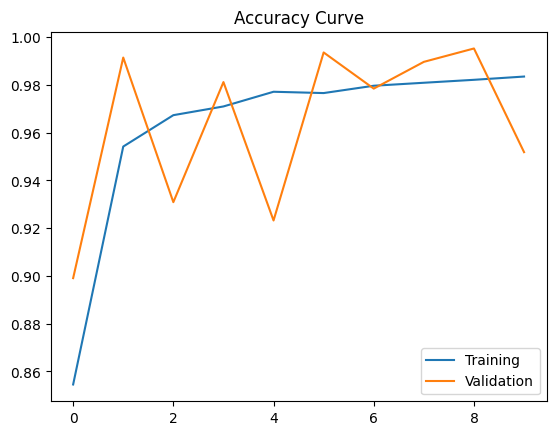

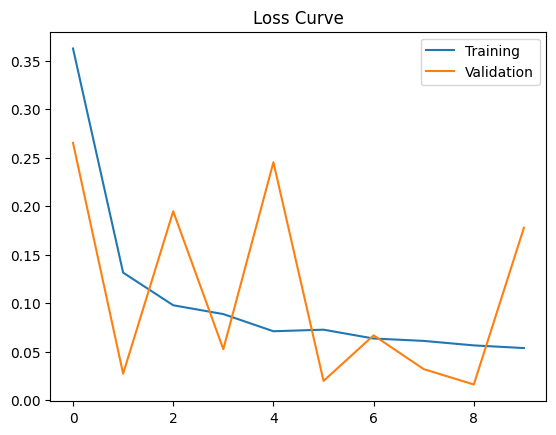

In [25]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

plt.legend(
    ["Training","Validation"]
)

plt.title("Accuracy Curve")

plt.show()
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

plt.legend(
    ["Training","Validation"]
)

plt.title("Loss Curve")

plt.show()

Phase 2: Transfer Learning

In [44]:
import keras

from keras import layers
from keras import models

from keras.applications import MobileNetV2

In [45]:
import keras

model = keras.models.load_model(
    "rice_model.keras"
)

Selected pretrained models:

1. MobileNetV2
- Lightweight model
- Suitable for mobile deployment

2. EfficientNetB0
- Balances accuracy and efficiency

3. ResNet50
- Deep network with residual connections

These models are selected to compare lightweight
and deeper architectures.

. Feature Extraction (Freeze pretrained layers)
First: MobileNetV2

In [46]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

Build model:

In [47]:
mobilenet_model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(5, activation="softmax")

])

Compile:

In [48]:
mobilenet_model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

Train + Track Time

In [49]:
start = time.time()


history_mobile = mobilenet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=5

)


mobile_time = time.time() - start


print("Training Time:", mobile_time)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 114s 55ms/step - accuracy: 0.9416 - loss: 0.1650 - val_accuracy: 0.9742 - val_loss: 0.0698
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.9657 - loss: 0.0974 - val_accuracy: 0.9751 - val_loss: 0.0670
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 40ms/step - accuracy: 0.9690 - loss: 0.0887 - val_accuracy: 0.9813 - val_loss: 0.0536
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 44ms/step - accuracy: 0.9724 - loss: 0.0802 - val_accuracy: 0.9780 - val_loss: 0.0600
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 40ms/step - accuracy: 0.9728 - loss: 0.0773 - val_accuracy: 0.9819 - val_loss: 0.0515
Training Time: 436.57507586479187


Fine Tuning (Unfreeze layers)

In [50]:
base_model.trainable = True


for layer in base_model.layers[:-30]:

    layer.trainable = False

Compile with small learning rate:

In [51]:
mobilenet_model.compile(

optimizer=tf.keras.optimizers.Adam(1e-5),

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

Train:

In [52]:
fine_history = mobilenet_model.fit(

train_ds,

validation_data=val_ds,

epochs=5

)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 116s 52ms/step - accuracy: 0.9390 - loss: 0.2396 - val_accuracy: 0.9809 - val_loss: 0.0569
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 126s 48ms/step - accuracy: 0.9785 - loss: 0.0637 - val_accuracy: 0.9873 - val_loss: 0.0403
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 147s 51ms/step - accuracy: 0.9852 - loss: 0.0449 - val_accuracy: 0.9864 - val_loss: 0.0419
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 135s 47ms/step - accuracy: 0.9890 - loss: 0.0326 - val_accuracy: 0.9893 - val_loss: 0.0347
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 47ms/step - accuracy: 0.9915 - loss: 0.0258 - val_accuracy: 0.9889 - val_loss: 0.0362


EfficientNet Experiment

In [53]:
efficient_base = EfficientNetB0(

weights="imagenet",

include_top=False,

input_shape=(224,224,3)

)


efficient_base.trainable=False

Model:

In [54]:
efficient_model=models.Sequential([

efficient_base,

layers.GlobalAveragePooling2D(),

layers.Dense(128,activation="relu"),

layers.Dropout(0.3),

layers.Dense(5,activation="softmax")

])

Compile:

In [55]:
efficient_model.compile(

optimizer="adam",

loss="sparse_categorical_crossentropy",

metrics=["accuracy"]

)

Train:

In [ ]:
history_eff=efficient_model.fit(

train_ds,

validation_data=val_ds,

epochs=5

)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 124s 54ms/step - accuracy: 0.9813 - loss: 0.0577 - val_accuracy: 0.9949 - val_loss: 0.0163
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 90s 48ms/step - accuracy: 0.9905 - loss: 0.0286 - val_accuracy: 0.9957 - val_loss: 0.0149
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 92s 49ms/step - accuracy: 0.9922 - loss: 0.0245 - val_accuracy: 0.9963 - val_loss: 0.0121
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 48ms/step - accuracy: 0.9932 - loss: 0.0219 - val_accuracy: 0.9949 - val_loss: 0.0148
Epoch 5/5
 200/1875 ━━━━━━━━━━━━━━━━━━━━ 1:08 41ms/step - accuracy: 0.9931 - loss: 0.0268

Compare Parameters

In [ ]:
print("Custom CNN Parameters:")
model1.summary()


print("MobileNet Parameters:")
mobilenet_model.summary()


print("EfficientNet Parameters:")
efficient_model.summary()

Error Analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


for images, labels in val_ds.take(1):

    preds = mobilenet_model.predict(images)

    predicted = np.argmax(preds,axis=1)


    wrong = np.where(
        predicted != labels.numpy()
    )[0]


    plt.figure(figsize=(10,5))


    for i,index in enumerate(wrong[:5]):

        plt.subplot(1,5,i+1)

        plt.imshow(images[index].numpy().astype("uint8"))

        plt.title(
            f"P:{classes[predicted[index]]}\nA:{classes[labels[index]]}"
        )

        plt.axis("off")


plt.show()

Final Report points

Chosen Model: MobileNetV2

Reason:
- High accuracy
- Faster inference
- Smaller size
- Suitable for deployment

EfficientNet gives better accuracy but requires
more computation.

Custom CNN has fewer features compared to pretrained
ImageNet models.

In [42]:
mobilenet_model.save("rice_model.keras")

In [43]:
from google.colab import files

files.download("rice_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>